# Image Segmentation on anevrisms

## 1. Applying image filtering

Some of the anevrisms are already segmented (patient 2 and patient 3): to remove the segmentation, one can apply a mean filter on the segmentaiton line: the idea is to remove the segmentation line, then replace its value with the value of a 2*2 mean filter

In [52]:
!pip install scikit-image
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 5.1 MB/s eta 0:00:0000:0100:01


In [3]:
!ls imgs

STD_AOST_PreStent.tif  patient1_seg.tif  patient3.tif
patient1_no_seg.bmp    patient2.tif


/home/user/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/user/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2432/3710255449.py:28: RuntimeWarning: invalid value encountered in cast
  img2[pixelx,pixely] = np.mean(mean_list, axis=0)


Text(0.5, 1.0, 'anv3')

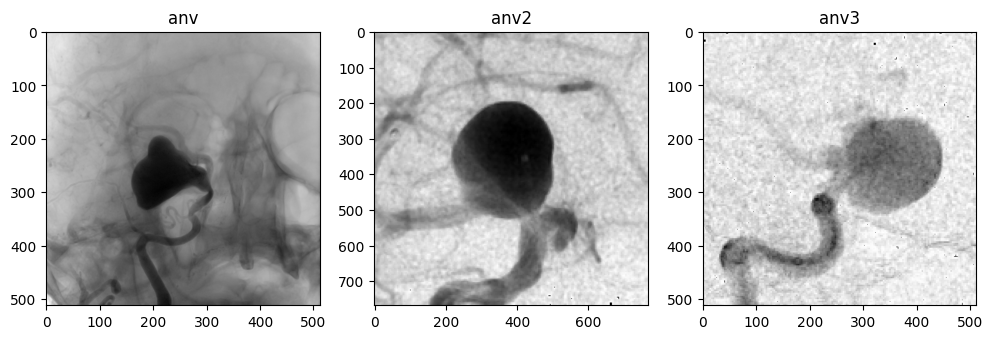

In [1]:
from skimage import graph, data, io, segmentation, color
import os
from matplotlib import pyplot as plt
from skimage.measure import regionprops
from skimage import draw
import numpy as np

anv = io.imread(os.path.join('imgs', 'patient1_no_seg.bmp'))
anv2 = io.imread(os.path.join('imgs', 'patient2.tif'))
anv3 = io.imread(os.path.join('imgs', 'patient3.tif'))
#anv = color.gray2rgb(anv)

def remove_seg(img):
    """return an image without its segmentations, using a mean filter.
    Mean filter 2*2 is applied only on the segmenation, leaving the rest as it is"""
    img2 = img.copy()
    for pixelx in range(img.shape[0]):
        for pixely in range(img.shape[1]):
    #         if np.all(img[pixelx,pixely]==np.array([0,255,255])) or np.all(img[pixelx,pixely]==np.array([0,255,0])) or\
    #         np.all(img[pixelx,pixely]==np.array([255,255,0])) or np.all(img[pixelx,pixely]==np.array([255,0,255])):
            if np.any(img[pixelx,pixely]==np.array([255,255,255])):
                mean_list = []
                for px in range(pixelx-1,pixelx+2):
                    for py in range(pixely-1, pixely+2):
                        if px < img.shape[0] and py < img.shape[1] and not np.any(img[px,py]==[255,255,255]) :
                            mean_list.append(img[px,py])

                    img2[pixelx,pixely] = np.mean(mean_list, axis=0)
        
    return img2

seg_ref_anv2 = anv2.copy()
anv2 = remove_seg(anv2)
anv3 = remove_seg(anv3)
fig, ax = plt.subplots(ncols=3, figsize=(12, 16))
ax[0].imshow(color.gray2rgb(anv))
ax[0].set_title("anv")
ax[1].imshow(anv2)
ax[1].set_title("anv2")
seg_ref_anv2_2 = seg_ref_anv2 * (seg_ref_anv2 == [0,255,0])

ax[2].imshow(anv3)
ax[2].set_title("anv3")


## 2. Applying Thresholding: 
skimage has a method to test and try all thresholds, so we can pick the one that works the best

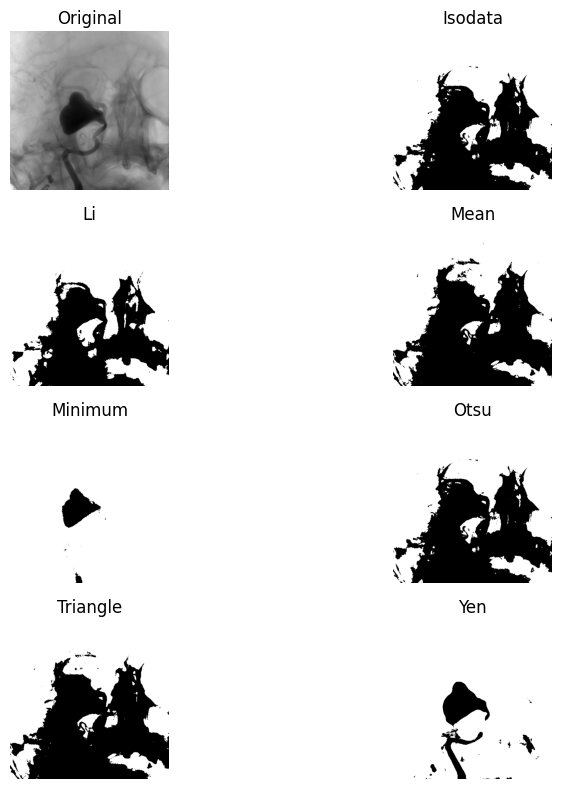

In [2]:
# testing thresholding on images
from skimage.filters import try_all_threshold

fig, ax = try_all_threshold(anv, figsize=(10, 8), verbose=False)
plt.show()

## 3. Applying Graph Cuts :

In order to compute a graph given an image, one should use an oversegmenting method. The oversegmenting method will regroup similar neighbor pixels into clusters. Then a graph (Region Adgency Graph) is established, assessing the difference between each clusters (nodes in graph), and attribuing edges (weights can be understood as strengths/differences between each clusters). Finally, Normalized cut will be applied for object segmentations. The goal of Normalized cut is to find edges 


In a nutshell; GraphCuts consists of:
- oversegmenting method
- normalized cuts
- get labels

Text(0.5, 1.0, 'anv3')

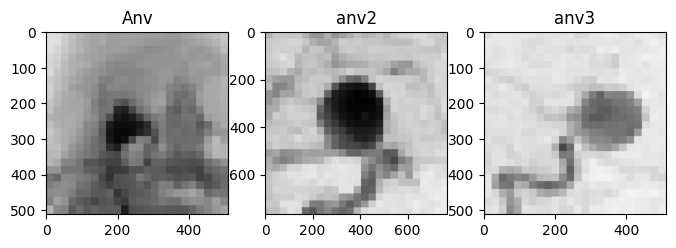

In [2]:
# using graph based method:
# practising over segmentation

def slic_method(img):
    """slic oversampling method"""
    if len(img.shape)> 2:
        img = color.rgb2gray(img)
    labels = segmentation.slic(img, compactness=30, n_segments=600, channel_axis=None)
    labels = labels + 1  # So that no labelled region is 0 and ignored by regionprops
    label_rgb = color.label2rgb(labels, img, kind='avg')
    return labels, label_rgb

labels_a1, label_rgb_a1 =  slic_method(anv)
labels_a2, label_rgb_a2 = slic_method(anv2)
labels_a3, label_rgb_a3 = slic_method(anv3)

fig, ax = plt.subplots(ncols=3,  figsize=(8,5))
ax[0].imshow(label_rgb_a1)
ax[0].set_title("Anv")

ax[1].imshow(label_rgb_a2)
ax[1].set_title("anv2")

ax[2].imshow(label_rgb_a3)
ax[2].set_title("anv3")

Text(0.5, 1.0, 'anv3')

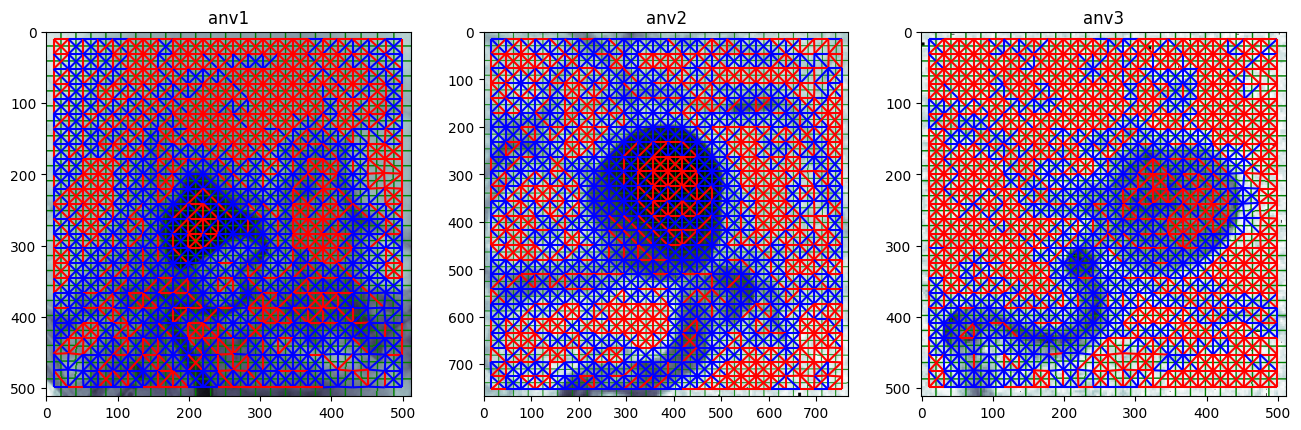

In [3]:
from skimage import graph
import matplotlib


def normalized_cut(img, label):
    
    g = graph.rag_mean_color(img, label, mode='similarity')
    labels2 = graph.cut_normalized(label, g)
    
    return g, labels2

blue_red = matplotlib.colors.ListedColormap(['blue', 'red'])

fig, ax = plt.subplots(ncols=3,  figsize=(16,10))
g_a1, labels2_a1 = normalized_cut(anv, labels_a1)

graph.show_rag(labels_a1, g_a1, color.gray2rgb(anv), border_color="green", edge_cmap=blue_red, ax = ax[0])
ax[0].set_title("anv1")

g_a2, labels2_a2 = normalized_cut(anv2, labels_a2)
graph.show_rag(labels_a2, g_a2, anv2, border_color="green", edge_cmap=blue_red, ax = ax[1])

ax[1].set_title("anv2")

g_a3, labels2_a3 = normalized_cut(anv3, labels_a3)
graph.show_rag(labels_a3, g_a3, anv3, border_color="green", edge_cmap=blue_red, ax = ax[2])
ax[2].set_title("anv3")

In [4]:
### Get cut

# TODO : identify circular shape among the shape found

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.5098039215686274].


(512, 512, 3) (512, 512, 3) (512, 512)
[  2 162 163 165 186 187 191 234 309 360 392 435 539 573 600]
{np.int64(2): 0, np.int64(162): 1, np.int64(163): 2, np.int64(165): 3, np.int64(186): 4, np.int64(187): 5, np.int64(191): 6, np.int64(234): 7, np.int64(309): 8, np.int64(360): 9, np.int64(392): 10, np.int64(435): 11, np.int64(539): 12, np.int64(573): 13, np.int64(600): 14}
debug 255 255 254
[  2 208 213 371 372 373 380 436 460 464 493]
{np.int64(2): 0, np.int64(208): 1, np.int64(213): 2, np.int64(371): 3, np.int64(372): 4, np.int64(373): 5, np.int64(380): 6, np.int64(436): 7, np.int64(460): 8, np.int64(464): 9, np.int64(493): 10}


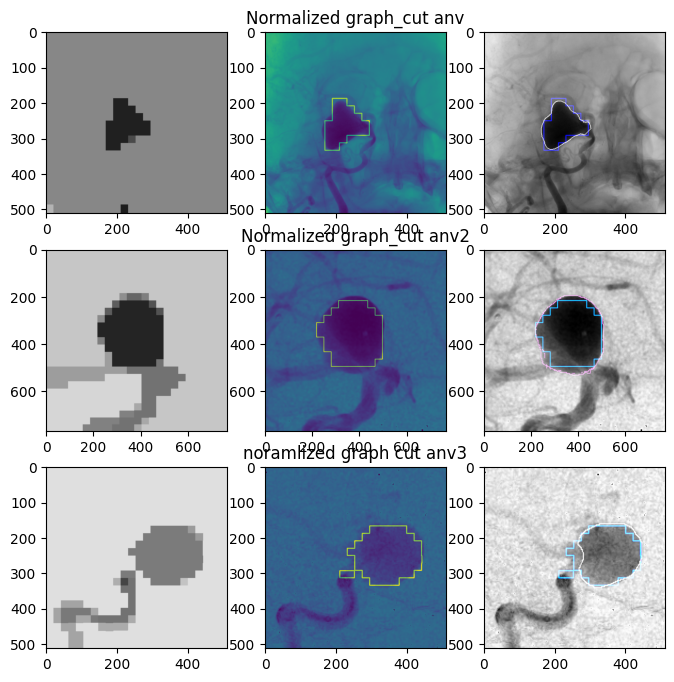

In [4]:
import cv2
from skimage.morphology import dilation
def get_handable_labels(labels):
    unique_labels = np.unique(labels)
    print(unique_labels)
    look_up_table = { x:i for i, x in enumerate(unique_labels)}
    print(look_up_table)
    for x in range(labels.shape[0]):
        for y in range(labels.shape[1]):
            labels[x,y] = look_up_table[labels[x,y]]
    return labels, [i for i in range(unique_labels.shape[0])]

def get_contour(mask):

    contours, hierarchy = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )
    canvas = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    return cv2.drawContours(canvas, contours, -1, (0, 0, 255), 2)

fig, ax = plt.subplots(nrows=3, ncols=3,   figsize=(8, 8))
ax[0,0].imshow(color.label2rgb(labels2_a1, anv, kind='avg'))
ax[0,1].set_title("Normalized graph_cut anv")

seg_ref = plt.imread("imgs/patient1_seg.tif")
seg_ref = (seg_ref[:, :, 0] > 100) & (seg_ref[:, :, 1] > 100) & (seg_ref[:, :, 2] < 100)

mask = ((labels2_a1 == 228)*255).astype(np.uint8)
cont = get_contour(mask)
ax[0,1].imshow( color.rgb2gray(cont)*2550 + anv)

print(cont.shape, color.gray2rgb(anv).shape, seg_ref.shape)
seg_ref = color.gray2rgb(seg_ref.astype(np.uint8) * 255)
#seg_ref[:,:,0] = seg_ref[:,:,0] * 2550
ax[0,2].imshow(  seg_ref*255 + cont*255 + color.gray2rgb(anv)/255) # color.gray2rgb(anv)/25

# img 2
seg_ref = io.imread(os.path.join('imgs', 'patient2.tif'))
seg_ref = (seg_ref[:,:,2]<140).astype(np.uint8) *(seg_ref == [0,255,0]).astype(np.uint8)[:,:,1]
seg_ref = color.gray2rgb(seg_ref.astype(np.uint8)*255)
seg_ref[:,:,1] = 255* seg_ref[:,:,1]
ax[1,0].imshow(color.label2rgb(labels2_a2, anv2, kind='avg'))
ax[1,1].set_title("Normalized graph_cut anv2")

labels2_a2_h, lk_up_table = get_handable_labels(labels2_a2)
mask = (labels2_a2_h== lk_up_table[5]).astype(np.uint8)
cont = get_contour(mask)
cont[:,:,0] = 255*cont[:,:,0]

ax[1,1].imshow(color.rgb2gray(cont)*25 + color.rgb2gray(anv2))
print("debug", np.max(seg_ref), np.max(cont), np.max(anv2))
ax[1,2].imshow( np.clip(
    dilation(seg_ref.astype(np.int16), ) +
    dilation(cont.astype(np.int16)) +
    anv2.astype(np.int16),
    0,
    255
).astype(np.uint8))# +cont*255 + anv2

ax[2,0].imshow(color.label2rgb(labels2_a3, anv3, kind='avg'))
ax[2,1].set_title("noramlized graph cut anv3")

seg_ref = io.imread(os.path.join('imgs', 'patient3.tif'))

seg_ref= ((seg_ref[:,:,1] > 250) & (seg_ref[:,:,0] < 10)).astype(np.uint8)
seg_ref = color.gray2rgb(seg_ref.astype(np.uint8)*255)
labels2_a3_h, lk_up_table = get_handable_labels(labels2_a3)
mask = ((labels2_a3_h== lk_up_table[1])*255).astype(np.uint8)
cont = get_contour(mask)
ax[2,1].imshow(color.rgb2gray(anv3) * mask)
ax[2,1].imshow(color.rgb2gray(anv3) + color.rgb2gray(cont)*25)


ax[2,2].imshow(np.clip(
    dilation(seg_ref.astype(np.int16), ) +
    dilation(cont.astype(np.int16)) +
    anv3.astype(np.int16),
    0,
    255
).astype(np.uint8))

In [47]:

print(seg_ref.shape)
print(seg_ref.ndim)
print(seg_ref.dtype)

(768, 768, 3)
3
uint8


## Evaluation

In [5]:
from evaluation_facility import evaluate_2d_seg, flood_fill

img_seg = plt.imread("imgs/patient1_seg.tif")

seg_ref = (img_seg[:, :, 0] > 100) & (img_seg[:, :, 1] > 100) & (img_seg[:, :, 2] < 100)

area_seg_computed =  ((labels2_a1 == 228)*255).astype(np.uint8)
area_seg_ref = flood_fill(seg_ref)

evaluate_2d_seg(area_seg_computed*255, area_seg_ref)

# img 2

anv2 = io.imread(os.path.join('imgs', 'patient2.tif'))
ref_seg_anv2 = (anv2[:,:,2]<140).astype(np.uint8) *(anv2 == [0,255,0]).astype(np.uint8)[:,:,1]
area_seg_ref2 = flood_fill(ref_seg_anv2)
area_seg_computed2 = (labels2_a2_h== lk_up_table[5]).astype(np.uint8)

evaluate_2d_seg(area_seg_computed2, area_seg_ref2) 



/home/user/vision/evaluation_facility.py:21: UserWarning: ignoring size because footprint is set
  output_array = np.maximum(input_array,sp.ndimage.grey_erosion(output_array, size=(3,3), footprint=el))


1128
1180
1128
1180
------------------------------------------------------------------------------------------------------------------------------------
IoU                 Dice                 Precision           Recall              F1-score            Hausdorff  Yasnoff             
------------------------------------------------------------------------------------------------------------------------------------
0.2243826560373323  0.20174825174825176  0.9011739968459787  0.8970870399441828  0.8991258741258742  11           0.018266979625738197
------------------------------------------------------------------------------------------------------------------------------------


/home/user/vision/evaluation_facility.py:21: UserWarning: ignoring size because footprint is set
  output_array = np.maximum(input_array,sp.ndimage.grey_erosion(output_array, size=(3,3), footprint=el))


15137
195
15137
195
-------------------------------------------------------------------------------------------------------------------------------------
IoU                  Dice                 Precision           Recall              F1-score            Hausdorff  Yasnoff             
-------------------------------------------------------------------------------------------------------------------------------------
0.24621808254376104  0.21922900938000459  0.8044492100197657  0.9968782518210197  0.8903854953099978  32           0.020803482332357043
-------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
# img 3
anv3 = io.imread(os.path.join('imgs', 'patient3.tif'))

ref_seg_anv3 = ((anv3[:,:,1] > 250) & (anv3[:,:,0] < 10)).astype(np.uint8)

area_seg_ref3 = flood_fill(ref_seg_anv3)
area_seg_computed3 = ((labels2_a3_h== lk_up_table[1])*255).astype(np.uint8)

evaluate_2d_seg(area_seg_computed3*255, area_seg_ref3)

/home/user/vision/evaluation_facility.py:21: UserWarning: ignoring size because footprint is set
  output_array = np.maximum(input_array,sp.ndimage.grey_erosion(output_array, size=(3,3), footprint=el))


2202
3611
2202
3611
------------------------------------------------------------------------------------------------------------------------------------
IoU                  Dice                 Precision           Recall              F1-score            Hausdorff  Yasnoff            
------------------------------------------------------------------------------------------------------------------------------------
0.24473728528123948  0.21805427912298142  0.9151575864991909  0.8680334758615649  0.8909728604385093  45           0.04941960725495266
------------------------------------------------------------------------------------------------------------------------------------


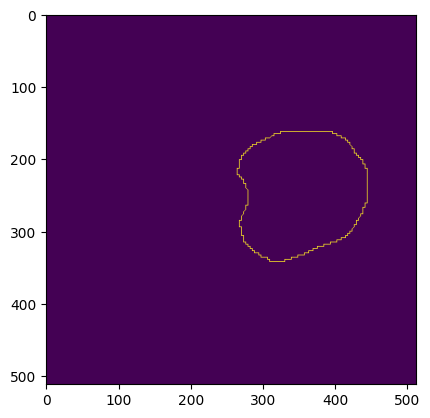

In [101]:
anv3 = io.imread(os.path.join('imgs', 'patient3.tif'))
plt.imshow((anv3[:,:,1] > 250) & (anv3[:,:,0] < 10))

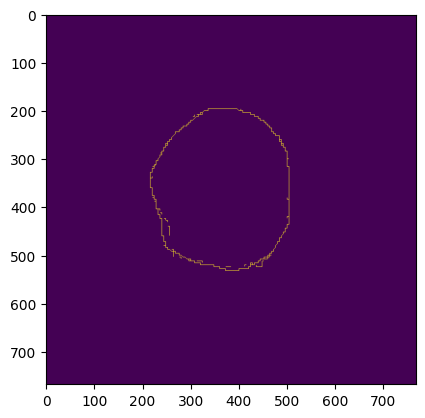

In [82]:
tt = (anv2[:,:,2]<140).astype(np.uint8) *(anv2 == [0,255,0]).astype(np.uint8)[:,:,1]
plt.imshow(tt)

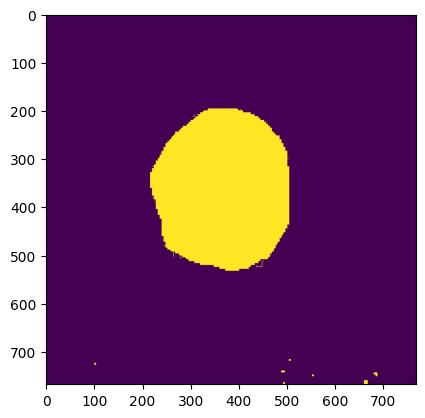

In [68]:
img = ref_seg_anv2
img = img[:,:,1]

img2 = img.copy()

mask = np.array([[1, 1, 1], 
                [1, 0,1], 
                [1, 1, 1]])

threshold = 255*4
limitx = mask.shape[0]//2
limity = mask.shape[1]//2

for x in range(limitx , img.shape[0] - limitx):
    for y in range(limity, img.shape[1] - limity):
        frag = img[x-limitx:x+limitx+1, y-limity: y+limity+1]
        
        frag2 = img2[img2.shape[0]-1- x - limitx :img2.shape[0] - x+limitx, \
                     img2.shape[1]-1 - y - limity :img2.shape[1]- y+limity]
        if np.sum((frag * mask)) >= threshold:
             img[x, y] = 255
        if np.sum((frag2*mask)) >= threshold:
             img2[img2.shape[0]-1- x, img2.shape[1]-1- y] = 255


plt.imshow(area_seg_ref)

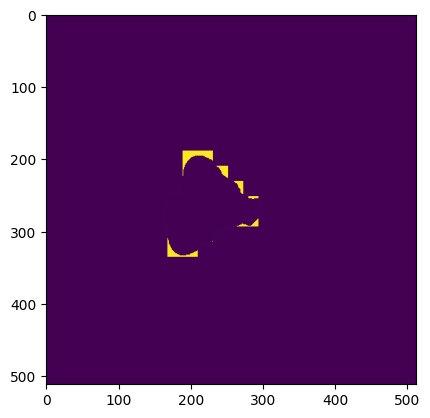

In [18]:
plt.imshow(area_seg_ref.astype("uint8") - seg_computed.astype("uint8")*255)

In [69]:

cont = get_contour(mask)
sv_img = cont[:,:,2]*255 

plt.imsave("test_seg.bmp", np.clip(sv_img, 0,255))

In [6]:
labels2_a2_h, lk_up_table = get_handable_labels(labels2_a2)
mask2 = (labels2_a2_h== lk_up_table[5]).astype(np.uint8)

cont_anv2 = get_contour(mask2)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
{np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(9): 9, np.int64(10): 10, np.int64(11): 11, np.int64(12): 12, np.int64(13): 13, np.int64(14): 14}


In [11]:
np.max(anv2[:,:,0] )

np.uint8(254)

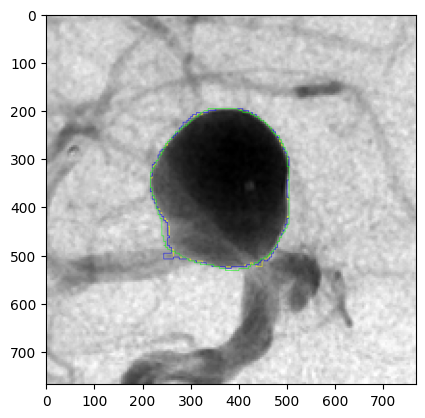

In [62]:
plt.imshow(anv2)

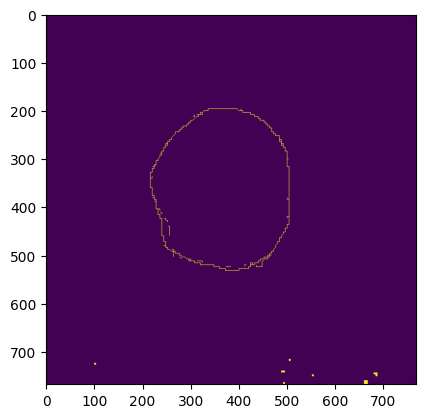

In [64]:

#ref_seg_anv2 = (anv2[:,:,0] >= 110) & (anv2[:,:,1]>=110)& (anv2[:,:,2] <= 140)
plt.imshow(ref_seg_anv2[:,:,1])

In [ ]:
## Graphcut with Felzenszwalb method

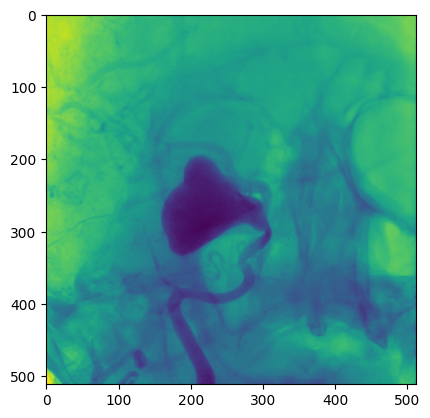

In [34]:
plt.imshow((cont[:,:,2]*255).astype('uint8') + anv )

In [38]:
img = (cont[:, :, 2] * 255).astype(np.uint8)
overlay = img + anv
print(overlay.min(), overlay.max(), overlay.dtype)

0 255 uint8


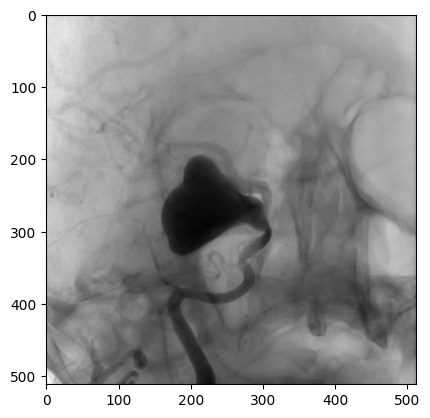

In [56]:
ttt = color.rgb2gray(np.clip(cont, 0,1)) + anv

mask = color.rgb2gray(np.clip(cont, 0,1)) * 255
ttt = np.clip(anv.astype(float) + mask, 0, 255).astype(np.uint8)

plt.imshow(ttt, cmap='gray')
plt.show()

In [39]:
print((cont[:, :, 2] * 255).astype("uint8").dtype)
print(anv.dtype)

uint8
uint8


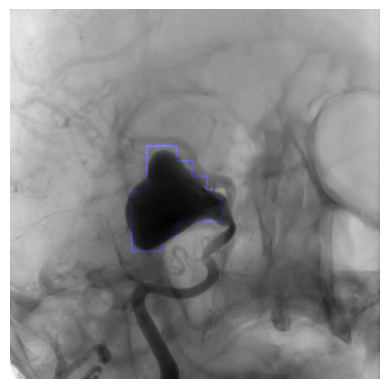

In [64]:
# Convert grayscale image to RGB
rgb = np.stack([anv, anv, anv], axis=-1).astype(np.uint8)

# Paint mask in red
rgb = rgb + rgb * cont*255

plt.imshow(rgb)
plt.axis('off')
plt.show()

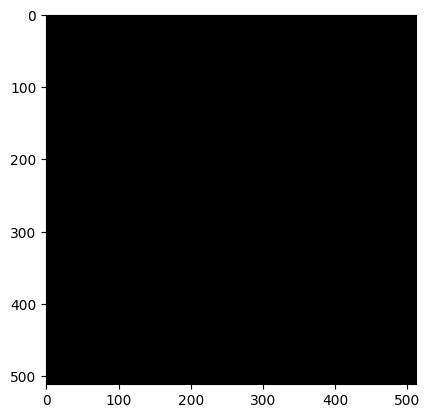

In [71]:
plt.imshow((rgb == [255,255,255]).astype("uint8"))


Method 1 — Shape filtering (recommended)

Intracranial aneurysms are approximately

round
elliptical
saccular

Compute for each segmentation:

Area

Perimeter

Circularity

C=
P
2
4πA
	​


Perfect circle:

C=1

Long vessel:

small circularity.

Also compute

eccentricity
solidity
compactness

Aneurysms usually have

high solidity
moderate circularity
low eccentricity.